<div align="center">
    <h1>Deep Learning: BERT Tokenizer in Natural Language Processing</h1>
</div>

In this notebook we will develop a **Sentiment Classifier** for an English **Twitter Dataset** by fine-tuning the pretrained model **BERT** available on [HuggingFace](https://huggingface.co/google-bert/bert-base-uncased/tree/main).

# Notebook Initialization Steps

## Connect to GPU
We will also make sure that we use a GPU device for better performance. In order for torch to use the GPU, we need to identify and specify the GPU as device. Later, we will load our data into the device.

In [124]:
import torch

# Connect to GPU device if it's available. Otherwise connect to CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('There are %d GPU(s) available.' % torch.cuda.device_count())
    print('We will use the GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: NVIDIA GeForce GTX 1070


## Theme Configuration
This step is just for demonstration purposes and initializes the **theme** of the plotting later on, and it is based on the current google drive theme.

### Getting the current theme
First we fetch the theme of google drive using **Javascript**.

In [125]:
theme = 'light' # Change this variable according to your prefernces ('light' or 'dark')

### Initializing the plotting theme
Next we set the theme colors of the plots we will generate later.

In [126]:
# Initialize some variables that define the colors of the plotting graphs
patch_background_color = '#404040' if theme == 'dark' else 'white'
plot_background_color = '#404040' if theme == 'dark' else 'white'
plot_grid_color = '#606060' if theme == 'dark' else 'lightgrey'
text_color = '#FFFFFF' if theme == 'dark' else 'black'

# Loading Tokenizer and Dataset
After configuring our notebook options, we will continue by loading the **tokenizer** and our **datasets** that we are going to use.

## Loading Datasets
Next we will load our Twitter Datasets, and create **Pandas dataframes** that we are going to work with later.

In [127]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore") # Ignore warnings
warnings.filterwarnings("ignore", category=UserWarning, module="nltk")

# Set the dataset path
base_folder = ".."
dataset_base_filepath = base_folder + '/Data'

# Load all the dataset files using pandas and store inside some dataframe variables
train_df = pd.read_csv(f'{dataset_base_filepath}/train_dataset.csv')
val_df = pd.read_csv(f'{dataset_base_filepath}/val_dataset.csv')
test_df = pd.read_csv(f'{dataset_base_filepath}/test_dataset.csv')

# Due to the fact that BERT is a very complex model and our data size is too big,
# we are going to use 10% of the dataset. This refers to both training and validation sets
size=0.01 # TODO: Change this variable to 0.1 if you want to use 10% of the dataset
train_df = train_df.sample(frac=size)
val_df = val_df.sample(frac=size)

print(train_df.shape, val_df.shape, test_df.shape)

(1484, 3) (424, 3) (21199, 2)


In [128]:
train_df.head()

,ID,Text,Label
22883,195578,yes its friday!,1
36763,55915,@mileycyrus Oh and have a great time at Elizab...,1
132145,31243,bad headaches are bad,0
7965,88049,i got my new moon wallpaper. cant wait for the...,1
96939,27988,Last rest day from running was May 21st. Don't...,1


In [129]:
from transformers import BertTokenizer

# Load the BERT tokenizer.
print('Loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

Loading BERT tokenizer...


Let's take a look at how the **BERT** tokenizer actually **tokenizes** the text and see the tokens **IDs**. We will use a random tweet from the training Dataframe.

In [130]:
import random

# Select a random tweet from the training dataset and produce its tokens and its IDs
random_tweet = list(train_df['Text'])[random.randint(0, len(train_df))]
tokenized_tweet = tokenizer.tokenize(random_tweet)
tokenized_tweet_ids = tokenizer.convert_tokens_to_ids(tokenized_tweet)

# Print the results
print(f'Original tweet: {random_tweet}')
print(f'Tokenized tweet: {tokenized_tweet}')
print(f'Tokenized tweet IDs: {tokenized_tweet_ids}')

Original tweet: Worried about little jacky 
Tokenized tweet: ['worried', 'about', 'little', 'jack', '##y']
Tokenized tweet IDs: [5191, 2055, 2210, 2990, 2100]


When we tokenize our data, we need to add **`[CLS]`** and **`[SEP]`** tokens at the start and at the end of each sentence respectively. We also need to determine the **maximum length** of our tokens in order to apply the **`[PAD]`** token too. Thankfully, the function **`encode`** will handle this for us.

In [131]:
def get_tokens_max_length(sentences):
    '''
    Receives a collection of sentences (strings) and returns the maximum
    length of the tokens.
    '''
    max_length = 0

    # For each sentence in the training dataset, produce its IDs
    # and determine the maximum length
    for i, sentence in enumerate(sentences):
        print(f" \r[...] Encoding sentence {i+1}/{len(sentences)}...", end="", flush=True)
        input_ids = tokenizer.encode(sentence, add_special_tokens=True)
        max_length = max(max_length, len(input_ids))

    print("\rAll sentences were encoded succesfully")

    return max_length

In [132]:
print("Getting maximum length of tokens...")
max_length = get_tokens_max_length(train_df['Text'])

Getting maximum length of tokens...
All sentences were encoded succesfully                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [133]:
print(f"Maximum sentence length: {max_length}")

Maximum sentence length: 60


As we can see the maximum length of our data is **259**. Let's now do the real encoding procedure to our training data, using the **`encode_plus()`** function. This function combines multiple steps for us:
1. Split the sentence into tokens.
2. Add the special `[CLS]` and `[SEP]` tokens.
3. Map the tokens to their IDs.
4. Pad or truncate all sentences to the same length.
5. Create the attention masks which explicitly differentiate real tokens from `[PAD]` tokens.

In [134]:
import time

def get_encoded_sentences(sentences, max_length):
    '''
    Receives a collection of sentences (strings) and returns its BERT tokenization IDs,
    and attention masks, using the encode_plus function. Special tokens [CLS], [SEP] are added
    automatically. All sentences are pad & truncated to the same specified length.
    '''

    # Initialize the input IDs and attention masks, lists
    input_ids = []
    attention_masks = []
    t0 = time.time()

    # Tokenize every sentence using the encode_plus function
    for i, sentence in enumerate(sentences):
        print(f" \r[...] Encoding sentence {i+1}/{len(sentences)}...", end="", flush=True)
        encoded_dict = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=max_length,
            pad_to_max_length=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    # Convert the input IDs and attention masks to tensors, and return them
    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    print(f" \r[Done] Sentences were encoded in {time.time() - t0} seconds")

    return input_ids, attention_masks

In [135]:
# Create the enoded data and the attention masks
print("Tokenizing the training dataset")
train_input_ids, train_attention_masks = get_encoded_sentences(train_df['Text'], max_length=max_length)

print("Tokenizing the validating dataset")
val_input_ids, val_attention_masks = get_encoded_sentences(val_df['Text'], max_length=max_length)

print("Tokenizing the testing dataset")
test_input_ids, test_attention_masks = get_encoded_sentences(test_df['Text'], max_length=max_length)

Tokenizing the training dataset
[...] Encoding sentence 1/1484...

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


[Done] Sentences were encoded in 1.931999921798706 seconds                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [136]:
# # Load the bert tokens
# train_input_ids = torch.load('/kaggle/input/bert-tokens/BERT/tokens/train_input_ids.pt')
# val_input_ids = torch.load('/kaggle/input/bert-tokens/BERT/tokens/val_input_ids.pt')
# test_input_ids = torch.load('/kaggle/input/bert-tokens/BERT/tokens/test_input_ids.pt')

# # Load the the attention masks
# train_attention_masks = torch.load('/kaggle/input/bert-tokens/BERT/attention_masks/train_attention_masks.pt')
# val_attention_masks = torch.load('/kaggle/input/bert-tokens/BERT/attention_masks/val_attention_masks.pt')
# test_attention_masks = torch.load('/kaggle/input/bert-tokens/BERT/attention_masks/test_attention_masks.pt')

In [137]:
from torch.utils.data import TensorDataset

# Create the Datasets for training, validation, and testing data
train_dataset = TensorDataset(train_input_ids, train_attention_masks, torch.tensor(train_df['Label'].values))
val_dataset = TensorDataset(val_input_ids, val_attention_masks, torch.tensor(val_df['Label'].values))
test_dataset = TensorDataset(test_input_ids, test_attention_masks)

In [138]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# Define the batch size
batch_size = 32

# Create the Dataloaders for training, validation, and testing data
train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)
test_loader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)

In [139]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels = 2,
    output_attentions = False,
    output_hidden_states = False,
)

if torch.cuda.device_count() > 1:
    model.cuda()
else:
    model.cpu()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [140]:
def train_one_epoch(model, train_loader, optimizer, scheduler, device):
    '''
    Trains the model for one epoch. Receives the model, the training dataloader,
    the optimizer, the learning rate scheduler and the device (GPU or CPU).
    Returns the average loss of the epoch.
    
    '''
    # Set the model to training mode, initialize the total loss
    # and iterate over the training dataloader
    model.train()
    total_loss = 0

    for i, batch in enumerate(train_loader):
        print(f" \r[...] Training batch {i+1}/{len(train_loader)}...", end="", flush=True)

        # Unpack the inputs from the dataloader, move them to the GPU, clear the gradients
        # and perform a forward pass to get the model's output
        b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
        model.zero_grad() 
        output = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

        # Get the loss and perform backpropagation
        loss = output.loss
        total_loss += loss.item()
        loss.backward()

        # Update the model parameters and the learning rate
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    # Compute the average loss over the epoch and return it
    avg_loss = total_loss / len(train_loader)
    return avg_loss

In [141]:
def evaluate_one_epoch(model, val_loader, device):
    '''
    Evaluates the model for one epoch. Receives the model, the validation dataloader
    and the device (GPU or CPU). Returns the average loss and accuracy of the epoch.
    
    '''
    # Set the model to evaluation mode, initialize the correct predictions and total predictions
    # and iterate over the validation dataloader
    model.eval()
    correct_predictions = 0
    total_predictions = 0
    batch_losses = []
    
    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            print(f" \r[...] Evaluating batch {i+1}/{len(val_loader)}...", end="", flush=True)

            # Unpack the inputs from the dataloader, move them to the GPU, and get the model's output
            b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
            output = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
            
            # Get the loss and the logits from the model's output
            loss, logits = output.loss, output.logits
            batch_losses.append(loss.item())
            
            # Compute the accuracy by comparing the predicted labels with the true labels
            predictions = torch.argmax(logits, dim=1).flatten()
            correct_predictions += (predictions == b_labels).sum().item()
            total_predictions += b_labels.size(0)
            
    # Compute the average loss and accuracy over the epoch and return them
    avg_loss = sum(batch_losses) / len(batch_losses)
    accuracy = correct_predictions / total_predictions
    
    return avg_loss, accuracy
            
            

In [142]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, device, epochs=4):
    '''
    Trains a BERT model for a specified number of epochs. It takes the model,
    the training and validation dataloaders, the optimizer, the learning rate scheduler,
    the device (GPU or CPU), and the number of epochs as input parameters.
    It returns the training and validation losses and accuracies as a pandas dataframe.
    
    '''
    # Initialize lists to store the training and validation losses and accuracies
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    # Move the model to the specified device (GPU or CPU) and train it 
    # for the specified number of epochs
    model.to(device)
    
    for epoch in range(epochs):
        
        # Train the model for one epoch and evaluate it on the validation set
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device)
        val_loss, val_accuracy = evaluate_one_epoch(model, val_loader, device)
        
        # Append the losses and accuracies to the lists
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        
        # Print the results for the current epoch
        print(f"\rEpoch {epoch+1}/{epochs}", end=" - ")
        print(f"Train Loss: {train_loss:.4f}", end=" - ")
        print(f"Validation Loss: {val_loss:.4f}", end=" - ")
        print(f"Validation Accuracy: {val_accuracy:.4f}")
        
    # Create a pandas dataframe to store the training and validation losses and accuracies
    return pd.DataFrame({
        'Train Loss': train_losses,
        'Validation Loss': val_losses,
        'Validation Accuracy': val_accuracies
    })

In [143]:
import torch
from transformers import get_scheduler
from torch.optim import AdamW

epochs = 3
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# Assuming training steps per epoch for scheduler
num_training_steps = epochs * len(train_loader)
scheduler = get_scheduler(
    "linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

training_results = train_model(
    model, train_loader, val_loader, optimizer, scheduler, device, epochs=epochs
)

Epoch 1/3 - Train Loss: 0.6227 - Validation Loss: 0.4765 - Validation Accuracy: 0.8137  
Epoch 2/3 - Train Loss: 0.4229 - Validation Loss: 0.4433 - Validation Accuracy: 0.8208  
Epoch 3/3 - Train Loss: 0.3110 - Validation Loss: 0.4586 - Validation Accuracy: 0.8255  


In [144]:
training_results.head()

,Train Loss,Validation Loss,Validation Accuracy
0,0.622685,0.476468,0.813679
1,0.422870,0.443327,0.820755
2,0.310966,0.458562,0.825472


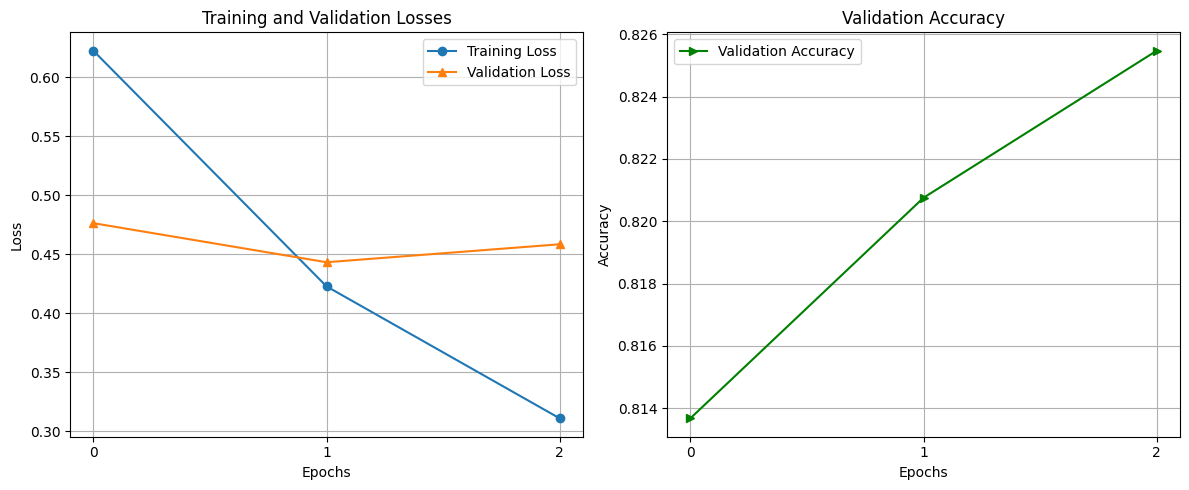

In [145]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(training_results['Train Loss'], '-o', label='Training Loss')
axes[0].plot(training_results['Validation Loss'], '-^', label='Validation Loss')
axes[0].grid(True)
axes[0].set_xticks(range(len(training_results)))
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Losses')
axes[0].legend()

axes[1].plot(training_results['Validation Accuracy'], '->', color='green', label='Validation Accuracy')
axes[1].grid(True)
axes[1].set_xticks(range(len(training_results)))
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [146]:
sentence = "I love this product! It's amazing and works great."
encoded_dict = tokenizer.encode_plus(
    sentence,
    add_special_tokens=True,
    max_length=max_length,
    pad_to_max_length=True,
    return_attention_mask=True,
    return_tensors='pt'
)

result = model(encoded_dict['input_ids'].to(device), encoded_dict['attention_mask'].to(device))
if int(torch.argmax(result.logits)) == 0:
    print("I believe this tweet is negative")
else:
    print("I believe this tweet is positive")

I believe this tweet is positive
